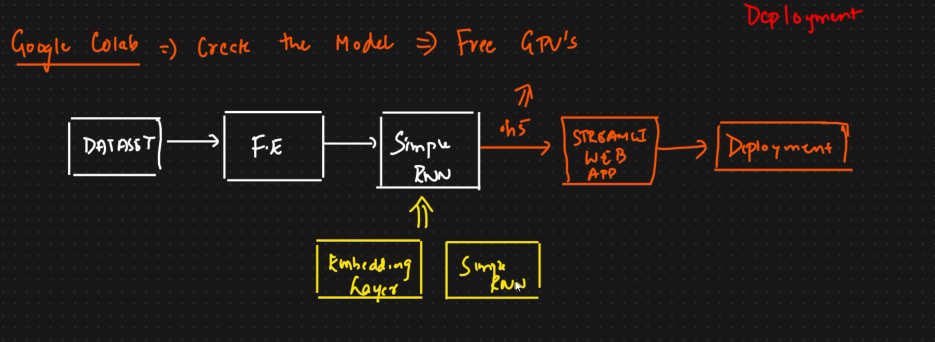

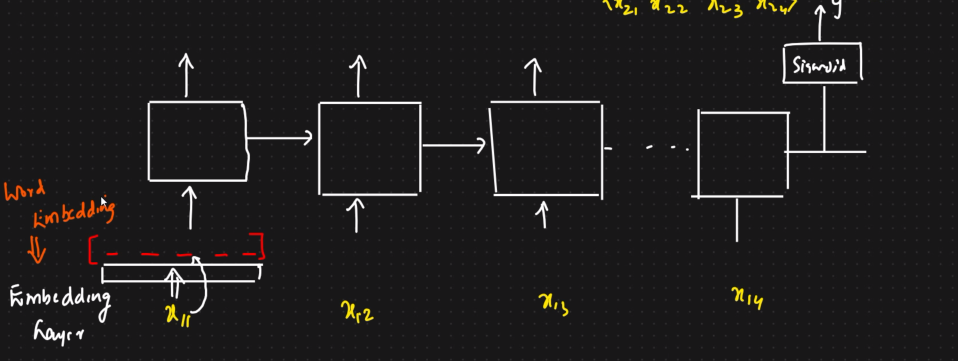

## End to end Deep Learning Project Using Simple RNN

# IMDb Dataset - Loading and Understanding the Data

## Import Required Libraries

```python
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
```

### Explanation

These libraries are required to build the Simple RNN model.

- **NumPy (`np`)** → Used for numerical computations.
- **TensorFlow (`tf`)** → Deep Learning framework.
- **IMDb Dataset** → Provides the movie review dataset.
- **sequence** → Used for sequence preprocessing such as padding.
- **Sequential** → Creates a neural network by stacking layers.
- **Embedding** → Converts word indices into dense vectors.
- **SimpleRNN** → Builds the Recurrent Neural Network.
- **Dense** → Fully connected output layer.

---

# Define Vocabulary Size

```python
max_features = 10000
```

### Explanation

The IMDb dataset contains thousands of unique words.

Instead of using every word, we keep only the **10,000 most frequent words**.

This helps to:

- Reduce memory usage.
- Reduce computation.
- Ignore very rare words.

---

# Load the IMDb Dataset

```python
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=max_features
)
```

### Explanation

This downloads and loads the IMDb movie review dataset.

The dataset is automatically divided into:

- **Training Set**
- **Testing Set**

The parameter

```python
num_words=max_features
```

means that only the top **10,000 most common words** are kept in the vocabulary.

Unlike normal text datasets, the reviews are **already converted into integer word indices**.

Example:

Instead of

```text
This movie was amazing
```

we get

```text
[1, 14, 20, 530]
```

where each integer represents a specific word.

---

# Display Dataset Shape

```python
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")
```

### Explanation

This displays the size of the dataset.

Example Output

```text
Training Data : (25000,)
Training Labels : (25000,)

Testing Data : (25000,)
Testing Labels : (25000,)
```

Meaning:

- **25,000 training reviews**
- **25,000 testing reviews**
- Each review has one corresponding label.

---

# Inspect a Sample Review

```python
sample_review = X_train[0]
sample_label = y_train[0]
```

### Explanation

Here, we select the **first review** from the training dataset.

- `sample_review` contains the review as integer word IDs.
- `sample_label` contains the sentiment.

Possible label values:

```text
1 → Positive Review

0 → Negative Review
```

---

# Print the Review and Label

```python
print(f"Sample review (as integers): {sample_review}")
print(f"Sample label: {sample_label}")
```

### Explanation

The review is displayed as a list of integers.

Example:

```text
[1, 14, 22, 16, 43, ...]
```

Each integer represents a word from the IMDb vocabulary.

The label tells whether the review is:

- Positive (1)
- Negative (0)

---

# Get the Word Dictionary

```python
word_index = imdb.get_word_index()
```

### Explanation

This returns a dictionary that maps words to integer IDs.

Example:

```text
"movie" → 17

"good" → 49

"bad" → 76
```

This mapping is used internally by the IMDb dataset.

---

# Reverse the Dictionary

```python
reverse_word_index = {
    value: key
    for key, value in word_index.items()
}
```

### Explanation

The original dictionary maps:

```text
Word → Integer
```

Example:

```text
good → 49
```

To convert integers back into words, we reverse the dictionary.

Now it becomes

```text
49 → good
```

This makes decoding reviews much easier.

---

# Decode the Review

```python
decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in sample_review]
)
```

### Explanation

The review currently contains integer IDs.

Example:

```text
[1, 14, 22, 16]
```

This code converts every integer back into its corresponding word.

### Why `i - 3`?

The IMDb dataset reserves the first few indices for special tokens such as:

- Padding
- Start of sequence
- Unknown words

Therefore, we subtract **3** before looking up the word.

### Why `.get()`?

```python
reverse_word_index.get(i - 3, '?')
```

- Returns the corresponding word if the index exists.
- Returns `"?"` if the word is not found.

---

# Join the Words

```python
' '.join(...)
```

After decoding, we obtain a list of words.

Example:

```text
['this', 'movie', 'was', 'great']
```

`join()` combines them into a readable sentence.

Output:

```text
this movie was great
```

Now the review looks like normal English instead of integer IDs.

---

# Workflow

```text
IMDb Dataset
      ↓
Load Dataset
      ↓
Reviews as Integer IDs
      ↓
Load Word Dictionary
      ↓
Reverse Dictionary
      ↓
Convert IDs Back to Words
      ↓
Readable Movie Review
```

---

# Key Points

- The IMDb dataset is already **integer encoded**.
- Only the **10,000 most frequent words** are loaded.
- Each review has a corresponding sentiment label.
- `word_index` maps **Word → Integer**.
- `reverse_word_index` maps **Integer → Word**.
- `i - 3` adjusts for special reserved tokens in the IMDb dataset.
- Decoding reviews is done only for understanding the data; the model is trained using the integer sequences.
````


In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [29]:
## Load the imdb dataset

max_features=10000 ##vocabulary size
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=max_features)

# Print the shape of the data
print(f'Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_train.shape}, Testing labels shape: {y_test.shape}')

Training data shape: (25000,), Training labels shape: (25000,)
Testing data shape: (25000,), Testing labels shape: (25000,)


In [30]:
X_train[0],y_train[0]

([1,
  14,
  22,
  16,
  43,
  530,
  973,
  1622,
  1385,
  65,
  458,
  4468,
  66,
  3941,
  4,
  173,
  36,
  256,
  5,
  25,
  100,
  43,
  838,
  112,
  50,
  670,
  2,
  9,
  35,
  480,
  284,
  5,
  150,
  4,
  172,
  112,
  167,
  2,
  336,
  385,
  39,
  4,
  172,
  4536,
  1111,
  17,
  546,
  38,
  13,
  447,
  4,
  192,
  50,
  16,
  6,
  147,
  2025,
  19,
  14,
  22,
  4,
  1920,
  4613,
  469,
  4,
  22,
  71,
  87,
  12,
  16,
  43,
  530,
  38,
  76,
  15,
  13,
  1247,
  4,
  22,
  17,
  515,
  17,
  12,
  16,
  626,
  18,
  2,
  5,
  62,
  386,
  12,
  8,
  316,
  8,
  106,
  5,
  4,
  2223,
  5244,
  16,
  480,
  66,
  3785,
  33,
  4,
  130,
  12,
  16,
  38,
  619,
  5,
  25,
  124,
  51,
  36,
  135,
  48,
  25,
  1415,
  33,
  6,
  22,
  12,
  215,
  28,
  77,
  52,
  5,
  14,
  407,
  16,
  82,
  2,
  8,
  4,
  107,
  117,
  5952,
  15,
  256,
  4,
  2,
  7,
  3766,
  5,
  723,
  36,
  71,
  43,
  530,
  476,
  26,
  400,
  317,
  46,
  7,
  4,
  2,
  1029,
  

In [31]:
## Inspect a sample review and its label
sample_review=X_train[0]
sample_label=y_train[0]

print(f"Sample review (as integers):{sample_review}")
print(f'Sample label: {sample_label}')


Sample review (as integers):[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample label: 1


In [32]:
### MApping of words index bacl to words(for understanding)
word_index=imdb.get_word_index()
#word_index
reverse_word_index = {value: key for key, value in word_index.items()}
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [33]:
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in sample_review])
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [34]:
from tensorflow.keras.preprocessing import sequence

max_len=500

X_train=sequence.pad_sequences(X_train,maxlen=max_len)
X_test = sequence.pad_sequences(X_test, maxlen=max_len)
X_train

array([[   0,    0,    0, ...,   19,  178,   32],
       [   0,    0,    0, ...,   16,  145,   95],
       [   0,    0,    0, ...,    7,  129,  113],
       ...,
       [   0,    0,    0, ...,    4, 3586,    2],
       [   0,    0,    0, ...,   12,    9,   23],
       [   0,    0,    0, ...,  204,  131,    9]],
      shape=(25000, 500), dtype=int32)

In [35]:
X_train[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

# Building and Training a Simple RNN for IMDb Sentiment Analysis

## Create the Sequential Model

```python
model = Sequential()
```

### Explanation

A **Sequential Model** is the simplest way to build a neural network in Keras.

Layers are added one after another in sequence.

---

# Add the Embedding Layer

```python
model.add(
    Embedding(
        max_features,
        128,
        input_length=max_len
    )
)
```

### Explanation

The Embedding layer converts **integer word IDs** into **dense vector representations**.

### Parameters

#### `max_features`

Represents the vocabulary size.

```text
max_features = 10000
```

The model learns embeddings for the **10,000 most frequent words**.

---

#### `128`

Embedding Dimension.

Every word is converted into a vector containing **128 numerical values**.

Example

```text
movie

↓

[0.12, -0.45, 0.78, ..., 0.34]
```

Initially, these vectors are random and become meaningful during training.

---

#### `input_length=max_len`

Specifies the length of every review after padding.

If

```text
max_len = 500
```

then every review contains exactly **500 word positions**.

---

# Add the Simple RNN Layer

```python
model.add(
    SimpleRNN(
        128,
        activation='relu'
    )
)
```

### Explanation

This is the main layer of the network.

The Simple RNN processes the review **one word at a time**, remembering information from previous words through its hidden state.

### Parameters

#### `128`

Number of RNN neurons (hidden units).

More neurons allow the model to learn more complex patterns but also increase computation.

---

#### `activation='relu'`

ReLU (Rectified Linear Unit) is used as the activation function.

Formula

```text
ReLU(x)

=

max(0, x)
```

Meaning

- If input > 0 → Output = Input
- If input ≤ 0 → Output = 0

ReLU helps the network learn non-linear relationships and speeds up training.

---

# Add the Output Layer

```python
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)
```

### Explanation

The Dense layer is the final prediction layer.

Since this is a **Binary Classification** problem, only **one output neuron** is required.

The Sigmoid activation converts the output into a probability.

Output Range

```text
0 to 1
```

Example

```text
0.92

↓

Positive Review
```

```text
0.08

↓

Negative Review
```

---

# Display Model Summary

```python
model.summary()
```

### Explanation

Displays information about the neural network.

It shows:

- Layer names
- Output shapes
- Number of trainable parameters
- Total parameters

This helps verify that the architecture has been built correctly.

---

# Compile the Model

```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

### Explanation

Before training, the model must be compiled.

### Optimizer

```text
Adam
```

Adam updates the weights using Backpropagation and is one of the most commonly used optimizers because it converges quickly and performs well in many deep learning tasks.

---

### Loss Function

```text
Binary Crossentropy
```

Since the problem has only two classes (Positive and Negative), Binary Crossentropy is the appropriate loss function.

The objective is to minimize this loss during training.

---

### Metric

```text
Accuracy
```

Accuracy measures the percentage of correctly classified reviews during training and validation.

---

# Import Early Stopping

```python
from tensorflow.keras.callbacks import EarlyStopping
```

### Explanation

EarlyStopping is a callback that monitors the model during training and stops training automatically when the model stops improving.

This helps prevent overfitting and saves training time.

---

# Create EarlyStopping Callback

```python
earlystopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
```

### Explanation

#### `monitor='val_loss'`

The callback monitors the **Validation Loss** after every epoch.

---

#### `patience=5`

If the validation loss does not improve for **5 consecutive epochs**, training stops automatically.

---

#### `restore_best_weights=True`

After training stops, the model restores the weights from the epoch where the validation loss was the lowest.

This ensures the best-performing model is retained.

---

# Train the Model

```python
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[earlystopping]
)
```

### Explanation

This starts the training process.

### `X_train`

Training reviews.

---

### `y_train`

Training labels (Positive or Negative).

---

### `epochs=10`

The model can train for a maximum of **10 complete passes** over the training data.

If EarlyStopping is triggered, training may stop before completing all 10 epochs.

---

### `batch_size=32`

Instead of processing all reviews together, the model processes **32 reviews at a time**.

Benefits:

- Faster training
- Lower memory usage
- More stable gradient updates

---

### `validation_split=0.2`

20% of the training data is reserved for validation.

Example

```text
Training Data

25000 Reviews

↓

80%

↓

Training

20000 Reviews

↓

20%

↓

Validation

5000 Reviews
```

Validation data is used only to evaluate the model during training and is not used for updating weights.

---

### `callbacks=[earlystopping]`

Applies the EarlyStopping callback during training.

If validation loss stops improving, training ends automatically.

---

# Training History

The `history` object stores training information such as:

- Training Loss
- Validation Loss
- Training Accuracy
- Validation Accuracy

These values can later be plotted to visualize the learning process.

---

# Save the Model

```python
model.save('simple_rnn_imdb.h5')
```

### Explanation

After training, the complete model is saved into an **HDF5 (.h5)** file.

The saved file contains:

- Model architecture
- Learned weights
- Optimizer state
- Training configuration

This allows the model to be loaded later without retraining.

Example

```text
simple_rnn_imdb.h5

↓

Load Anytime

↓

Predict New Movie Reviews
```

---

# Complete Workflow

```text
IMDb Dataset
      ↓
Padding
      ↓
Embedding Layer
      ↓
Simple RNN
      ↓
Dense Layer (Sigmoid)
      ↓
Compile Model
      ↓
Train Model
      ↓
Early Stopping
      ↓
Save Model (.h5)
```

---

# Key Points

- **Embedding Layer** converts integer word IDs into dense vectors.
- **Simple RNN** learns patterns by processing one word at a time.
- **Dense + Sigmoid** performs binary sentiment classification.
- **Adam** optimizer updates the weights efficiently.
- **Binary Crossentropy** is used because the problem has two classes.
- **EarlyStopping** prevents overfitting by stopping training when validation loss no longer improves.
- The trained model is saved as **`simple_rnn_imdb.h5`** for future predictions and deployment.
````


In [36]:
## Train Simple RNN
model=Sequential()
model.add(Embedding(max_features,128,input_length=max_len)) ## Embedding Layers
model.add(SimpleRNN(128,activation='tanh')) ## Simple RNN Layer
model.add(Dense(1,activation="sigmoid"))

In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [40]:
## Create an instance of EarlyStoppping Callback
from tensorflow.keras.callbacks import EarlyStopping
earlystopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
earlystopping

In [41]:
## Train the model with early sstopping
history=model.fit(
    X_train,y_train,epochs=10,batch_size=32,
    validation_split=0.2,
    callbacks=[earlystopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 109ms/step - accuracy: 0.5685 - loss: 0.6725 - val_accuracy: 0.6244 - val_loss: 0.6365
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.6826 - loss: 0.5964 - val_accuracy: 0.6394 - val_loss: 0.6206
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.7650 - loss: 0.4852 - val_accuracy: 0.7426 - val_loss: 0.5347
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 103ms/step - accuracy: 0.7986 - loss: 0.4251 - val_accuracy: 0.6664 - val_loss: 0.6366
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.8436 - loss: 0.3614 - val_accuracy: 0.7534 - val_loss: 0.5767
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.8481 - loss: 0.3360 - val_accuracy: 0.6338 - val_loss: 0.6528
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.7520 - loss: 0.4862 - val_accuracy: 0.6672 - val_loss: 0.6687
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.7933 - loss: 0

In [14]:
## Save model file
model.save('simple_rnn_imdb.h5')